Design and implement a Convolutional Neural Network (CNN) for image classification using
sugarcane leaf disease


In [ ]:
import kagglehub

# Download Sugarcane Leaf Disease Dataset
path = kagglehub.dataset_download(
    "sunilgautam/sugarcane-leaf-disease-dataset"
)

print("Path to dataset files:", path)

100%|██████████| 160M/160M [00:02<00:00, 82.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/sunilgautam/sugarcane-leaf-disease-dataset/versions/1


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

# Configuration
BATCH_SIZE = 32
IMG_SIZE = (128, 128)

# Dataset path
adjusted_path = path

In [ ]:
# Load datasets
train_ds = tf.keras.utils.image_dataset_from_directory(
    adjusted_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    adjusted_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

print(f"Detected classes: {class_names}")

Found 2521 files belonging to 5 classes.
Using 2017 files for training.
Found 2521 files belonging to 5 classes.
Using 504 files for validation.
Detected classes: ['Healthy', 'Mosaic', 'RedRot', 'Rust', 'Yellow']


In [ ]:
# Optimize for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Build CNN Model
num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),

    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
EPOCHS = 10

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.3416 - loss: 1.4677 - val_accuracy: 0.4008 - val_loss: 1.3577
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 61s 954ms/step - accuracy: 0.4993 - loss: 1.2012 - val_accuracy: 0.5417 - val_loss: 1.2617
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 985ms/step - accuracy: 0.6187 - loss: 1.0006 - val_accuracy: 0.6706 - val_loss: 0.8722
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 988ms/step - accuracy: 0.6515 - loss: 0.8896 - val_accuracy: 0.6925 - val_loss: 0.7893
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 983ms/step - accuracy: 0.7149 - loss: 0.7442 - val_accuracy: 0.7282 - val_loss: 0.7421
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 82s 980ms/step - accuracy: 0.7541 - loss: 0.6406 - val_accuracy: 0.7679 - val_loss: 0.6776
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 63s 994ms/step - accuracy: 0.7774 - loss: 0.5725 - val_accuracy: 0.7579 - val_loss: 0.6237
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 81s 988ms/step - accuracy: 0.8156 - loss: 0.5048 - val_accurac

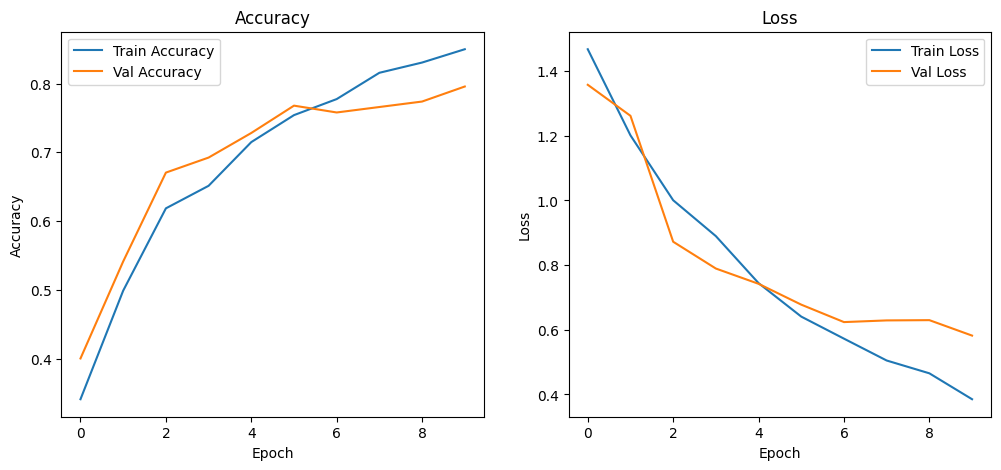

In [ ]:
# Get training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot results
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()